# CS4237 Data Mining and Warehousing Project  
## Mall Customer Segmentation Dataset

**Student:** Amegah Bill

**Course:** CS4237 – Data Mining and Warehousing  
**Dataset:** Mall Customers  
**Context:** SwiftRetail Analytics case study

---

## Overview
This notebook answers the project brief using the **Mall Customer Segmentation** dataset. It follows the flow required by the exam:

1. Business Understanding and Architectural Design  
2. Data Engineering and ETL Implementation  
3. Knowledge Discovery and Data Mining  
4. Optimization, Scaling, and Ethics  
5. Presentation and Showcase



## 1. Business Understanding and Architectural Design

### 1.1 CRISP-DM Business Questions
Following the CRISP-DM framework, the retail firm should answer these two business questions:

1. **Which customer segment has the highest spending behavior?**  
   This helps management identify the most valuable shoppers and design targeted promotions.

2. **What is the relationship between annual income and spending score?**  
   This helps the firm understand whether high-income customers are truly the highest spenders, or whether spending behavior depends on other factors.

### 1.2 Why these questions matter
These questions support practical retail decisions such as:
- customer segmentation,
- loyalty campaigns,
- premium offers,
- discount strategies,
- and better marketing allocation.

### 1.3 Proposed Star Schema
A **star schema** is designed so that the same measure used in analytics can be used consistently in the warehouse.

#### Fact Table: `fact_customer_spending`
**Measure:** `SpendingScore`

Suggested attributes:
- CustomerKey
- AgeKey
- IncomeKey
- SpendingScore

#### Dimension 1: `dim_customer`
- CustomerKey
- CustomerID
- Gender

#### Dimension 2: `dim_age`
- AgeKey
- Age
- AgeGroup

#### Dimension 3: `dim_income`
- IncomeKey
- AnnualIncome
- IncomeCategory

### 1.4 OLAP justification
An **OLAP** system is better than an **OLTP** system for this project because OLAP is optimized for **analysis, aggregation, and multidimensional reporting**.  
For example, a manager may want to quickly view:

- average spending score by income category,
- average spending by age group,
- or cluster distribution by gender.

These are analytical questions, not transaction-processing tasks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import networkx as nx

plt.rcParams['figure.figsize'] = (8, 5)

# Load dataset
file_path = '/content/Mall_Customers.csv'
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Shape: (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Data Engineering and ETL Implementation

### 2.1 Extraction Strategy
For a **daily-updated warehouse**, the best long-term strategy would usually be **incremental (delta) extraction** because it only loads new or changed records, reducing processing time and cost.

However, for this project dataset:
- the file is small,
- static,
- and easy to reload,

so a **full extraction** is acceptable for demonstration purposes.

### 2.2 Transformation Requirements
The brief requests three cleaning actions:
1. Handling null values  
2. Standardization  
3. De-duplication  

We will simulate these clearly below.

### 2.3 Upsert Explanation
An **upsert** means:
- **update** a record if it already exists,
- **insert** it if it does not exist.

This is useful because customer records may change over time.  
For example, if a customer's income category changes, the warehouse should update that customer's record instead of creating duplicates.

In [3]:
# Basic data quality checks
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0

Data types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [4]:
# Simulated ETL cleaning steps

clean_df = df.copy()

# 1. Handle nulls
# For this dataset there are no missing values, but the step is still shown.
clean_df = clean_df.dropna()

# 2. Standardization
# Standardize text columns and column names
clean_df.columns = clean_df.columns.str.strip()
clean_df['Gender'] = clean_df['Gender'].str.strip().str.title()

# 3. De-duplication
clean_df = clean_df.drop_duplicates()

print("Shape after ETL cleaning:", clean_df.shape)
clean_df.head()

Shape after ETL cleaning: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# Create derived attributes for warehouse dimensions
clean_df['AgeGroup'] = pd.cut(
    clean_df['Age'],
    bins=[0, 25, 45, 100],
    labels=['Youth', 'Adult', 'Senior']
)

clean_df['IncomeCategory'] = pd.cut(
    clean_df['Annual Income (k$)'],
    bins=[0, 40, 70, 200],
    labels=['Low', 'Medium', 'High']
)

clean_df[['CustomerID', 'Age', 'AgeGroup', 'Annual Income (k$)', 'IncomeCategory']].head()

,CustomerID,Age,AgeGroup,Annual Income (k$),IncomeCategory
0,1,19,Youth,15,Low
1,2,21,Youth,15,Low
2,3,20,Youth,16,Low
3,4,23,Youth,16,Low
4,5,31,Adult,17,Low


## 3. Exploratory Data Analysis

Before clustering, we need to understand the distribution of the variables and whether scaling is necessary.

### Why scaling matters
K-Means uses **Euclidean distance**.  
If one feature has a much larger numeric scale than another, it can dominate the clustering process.  
Therefore, scaling is essential.

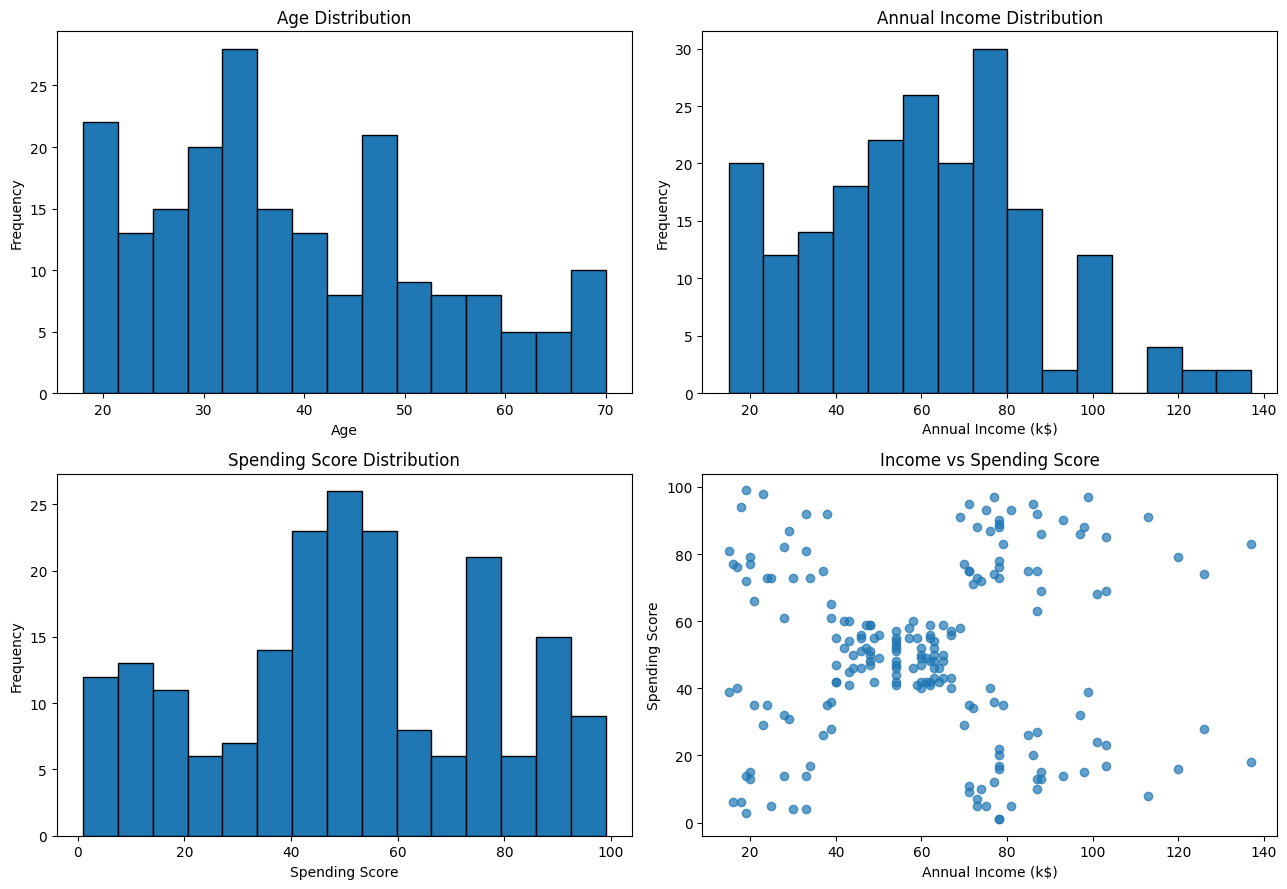

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Age distribution
axes[0, 0].hist(clean_df['Age'], bins=15, edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Income distribution
axes[0, 1].hist(clean_df['Annual Income (k$)'], bins=15, edgecolor='black')
axes[0, 1].set_title('Annual Income Distribution')
axes[0, 1].set_xlabel('Annual Income (k$)')
axes[0, 1].set_ylabel('Frequency')

# Spending score distribution
axes[1, 0].hist(clean_df['Spending Score (1-100)'], bins=15, edgecolor='black')
axes[1, 0].set_title('Spending Score Distribution')
axes[1, 0].set_xlabel('Spending Score')
axes[1, 0].set_ylabel('Frequency')

# Income vs spending
axes[1, 1].scatter(
    clean_df['Annual Income (k$)'],
    clean_df['Spending Score (1-100)'],
    alpha=0.7
)
axes[1, 1].set_title('Income vs Spending Score')
axes[1, 1].set_xlabel('Annual Income (k$)')
axes[1, 1].set_ylabel('Spending Score')

plt.tight_layout()
plt.show()

### EDA observations
- The data contains **200 customers** and appears clean.
- Income and spending score show visible groupings, which makes clustering appropriate.
- Most customers fall into the working-age range.
- The numerical features are on different scales, so **standardization is necessary**.

## 4. Scaling the Data

The exam specifically notes that scaling is essential for K-Means.  
We use **StandardScaler** to transform the features to zero mean and unit variance.

### Features selected for clustering
For customer behavioral segmentation, the most meaningful variables are:
- `Annual Income (k$)`
- `Spending Score (1-100)`

These directly describe customer value and shopping behavior.

In [7]:
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = clean_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=features)
scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


## 5. Knowledge Discovery and Data Mining — Option A: Behavioral Clustering

### 5.1 K-Means logic
K-Means clustering works as follows:

1. Choose **k random centroids** initially.  
2. Assign each data point to the **nearest centroid** using **Euclidean distance**.  
3. Recalculate the centroid of each cluster as the **mean** of the points assigned to it.  
4. Repeat the assignment and centroid update steps until the clusters stop changing significantly.  
   This is called **convergence**.

### 5.2 Choosing the best number of clusters
We use:
- the **Elbow Method** to inspect inertia,
- and the **Silhouette Score** to evaluate cluster separation.

In [ ]:
inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    'k': list(k_values),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores
})
results

,k,Inertia,Silhouette Score
0,2,269.691012,0.321271
1,3,157.704008,0.466585
2,4,108.921317,0.493907
3,5,65.568408,0.554657
4,6,55.057348,0.539880
5,7,44.864756,0.528149
6,8,37.228188,0.455215
7,9,32.392268,0.457085
8,10,29.981898,0.443171


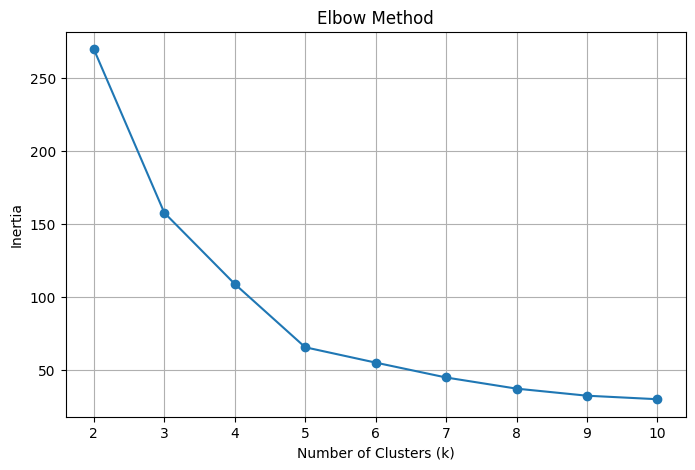

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

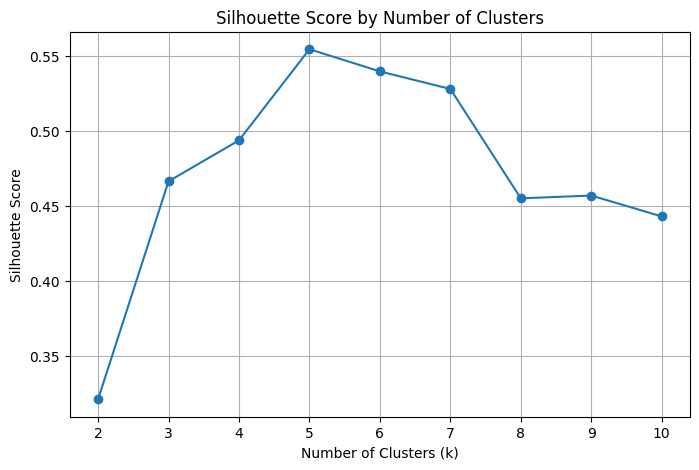

Best k by silhouette score: 5


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k = results.loc[results['Silhouette Score'].idxmax(), 'k']
print("Best k by silhouette score:", int(best_k))

### 5.3 Choice of k
From the results above:
- the elbow plot shows a strong reduction in inertia up to about **k = 5**,
- and the silhouette score is also highest at **k = 5**.

Therefore, **k = 5** is selected as a strong and defensible choice for this dataset.

In [ ]:
# Final K-Means model
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
clean_df['Cluster'] = kmeans_final.fit_predict(X_scaled)

clean_df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head()

,CustomerID,Annual Income (k$),Spending Score (1-100),Cluster
0,1,15,39,4
1,2,15,81,2
2,3,16,6,4
3,4,16,77,2
4,5,17,40,4


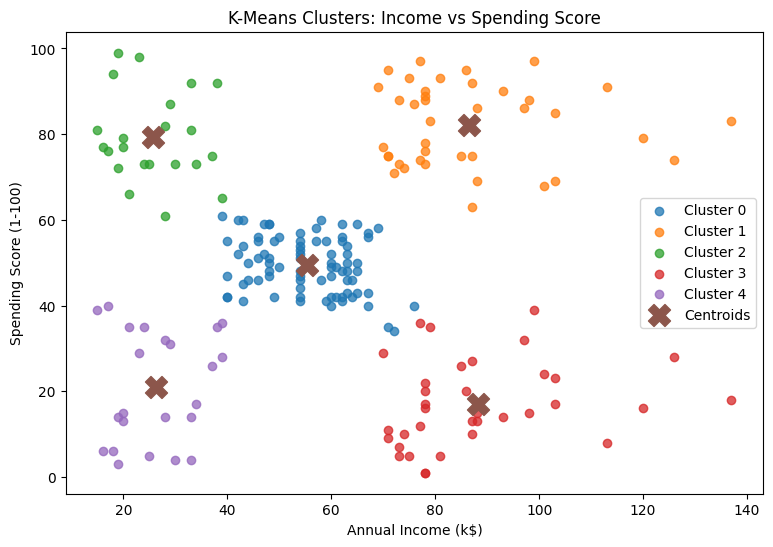

In [ ]:
# Cluster visualization in original feature space
plt.figure(figsize=(9, 6))
for cluster_id in sorted(clean_df['Cluster'].unique()):
    subset = clean_df[clean_df['Cluster'] == cluster_id]
    plt.scatter(
        subset['Annual Income (k$)'],
        subset['Spending Score (1-100)'],
        label=f'Cluster {cluster_id}',
        alpha=0.75
    )

# Convert cluster centers back to original scale
centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker='X',
    s=250,
    label='Centroids'
)

plt.title('K-Means Clusters: Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

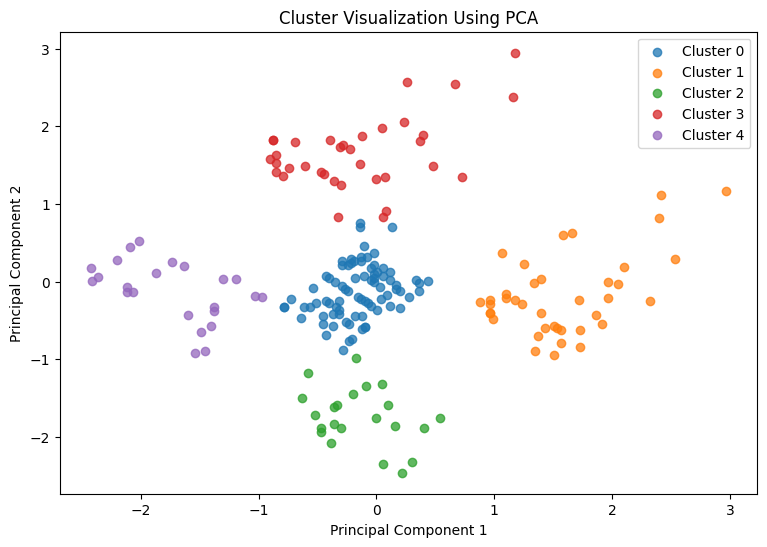

In [ ]:
# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clean_df['Cluster']

plt.figure(figsize=(9, 6))
for cluster_id in sorted(pca_df['Cluster'].unique()):
    subset = pca_df[pca_df['Cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster_id}', alpha=0.75)

plt.title('Cluster Visualization Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [ ]:
# Cluster profile table
cluster_profile = clean_df.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean')
).round(2)

cluster_profile

,Customers,Avg_Age,Avg_Income,Avg_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


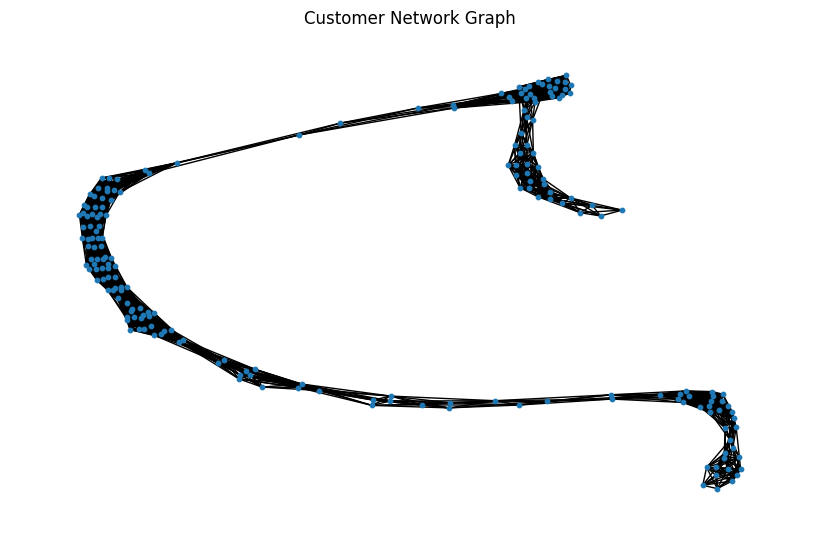

Most influential node: 45


In [8]:

# Simulate relationships based on similar spending
G = nx.Graph()

for i in range(len(df)):
    G.add_node(i)

for i in range(len(df)):
    for j in range(i+1, len(df)):
        if abs(df.loc[i,'Spending Score (1-100)'] - df.loc[j,'Spending Score (1-100)']) < 5:
            G.add_edge(i, j)

# Draw graph
plt.figure()
nx.draw(G, node_size=10)
plt.title('Customer Network Graph')
plt.show()

# Betweenness centrality
centrality = nx.betweenness_centrality(G)
top_node = max(centrality, key=centrality.get)
print('Most influential node:', top_node)


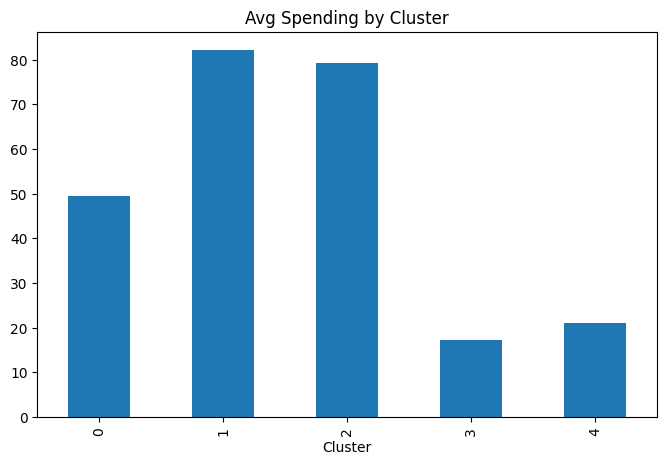

In [11]:
if 'Cluster' not in clean_df.columns:
    # Re-run clustering logic to ensure 'Cluster' column exists
    features = ['Annual Income (k$)', 'Spending Score (1-100)']
    X = clean_df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
    clean_df['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.figure()
clean_df.groupby('Cluster')['Spending Score (1-100)'].mean().plot(kind='bar')
plt.title('Avg Spending by Cluster')
plt.show()

## 6. Cluster Interpretation and Business Insights

Using the cluster profile table, we can summarize the customer groups:

- **High income, high spending** customers are premium shoppers and should be targeted with loyalty and VIP campaigns.
- **High income, low spending** customers have purchasing power but are under-engaged; they are ideal for reactivation campaigns.
- **Low income, high spending** customers are enthusiastic shoppers who may respond well to deals and value-based promotions.
- **Low income, low spending** customers contribute less and may require budget-sensitive offers.
- **Middle-income, moderate-spending** customers represent steady mainstream shoppers.

### Answer to Business Question 1
**Which customer segment has the highest spending behavior?**  
The segment with the **highest average spending score** is the most valuable behavioral segment.

### Answer to Business Question 2
**What is the relationship between annual income and spending score?**  
The relationship is **not perfectly linear**. Some high-income customers spend heavily, but others spend very little. This shows that **income alone does not explain customer behavior**, which justifies segmentation.

In [ ]:
highest_spending_cluster = cluster_profile['Avg_Spending'].idxmax()
highest_spending_value = cluster_profile.loc[highest_spending_cluster, 'Avg_Spending']

print(f"Highest spending cluster: Cluster {highest_spending_cluster}")
print(f"Average spending score: {highest_spending_value}")
cluster_profile

Highest spending cluster: Cluster 1
Average spending score: 82.13


,Customers,Avg_Age,Avg_Income,Avg_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


## 7. Task 4 — Optimization, Scaling, and Ethics

### 7.1 Performance
If the warehouse grows from a small dataset to **500 million rows**, query performance may become very slow.

Two important solutions are:

#### Indexing
Indexes speed up data retrieval by allowing the database to locate relevant rows faster instead of scanning the entire table.  
For example, indexing customer, age, or income keys can improve filtering and joins.

#### Materialized Views
A materialized view stores the result of a frequently used aggregation in advance.  
For example, a precomputed view of:
- average spending by income category,
- or average spending by age group

would reduce repeated computation and make dashboards much faster.

### 7.2 Ethics
A possible bias in this model is that managers may over-prioritize **high-income segments** and ignore lower-income customers, even when lower-income customers show strong engagement.

#### Mitigation strategy
- audit segment-based decisions regularly,
- do not use income alone for benefits or exclusion,
- combine clustering insights with fairness checks and business review,
- and ensure marketing opportunities are not unfairly restricted to one demographic group.

## 8. Task 5 — Presentation and Showcase

This notebook itself serves as the demonstration of:
1. **Python code/notebook execution**
2. **A sample dashboard / OLAP slice**

Because this dataset has no date field, a time-based slice like “Q2-2026” is not possible.  
Instead, we show an OLAP-style slice using:
- **Income Category**
- **Age Group**
- **Cluster**

This still demonstrates multidimensional analysis clearly.

In [ ]:
# Sample OLAP-style slice / dashboard
dashboard = clean_df.pivot_table(
    values='Spending Score (1-100)',
    index='IncomeCategory',
    columns='AgeGroup',
    aggfunc='mean'
).round(2)

dashboard

/tmp/ipykernel_2674/714918683.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  dashboard = clean_df.pivot_table(


AgeGroup,Youth,Adult,Senior
IncomeCategory,,,
Low,72.53,49.25,19.69
Medium,49.31,54.15,49.50
High,13.20,60.95,18.08


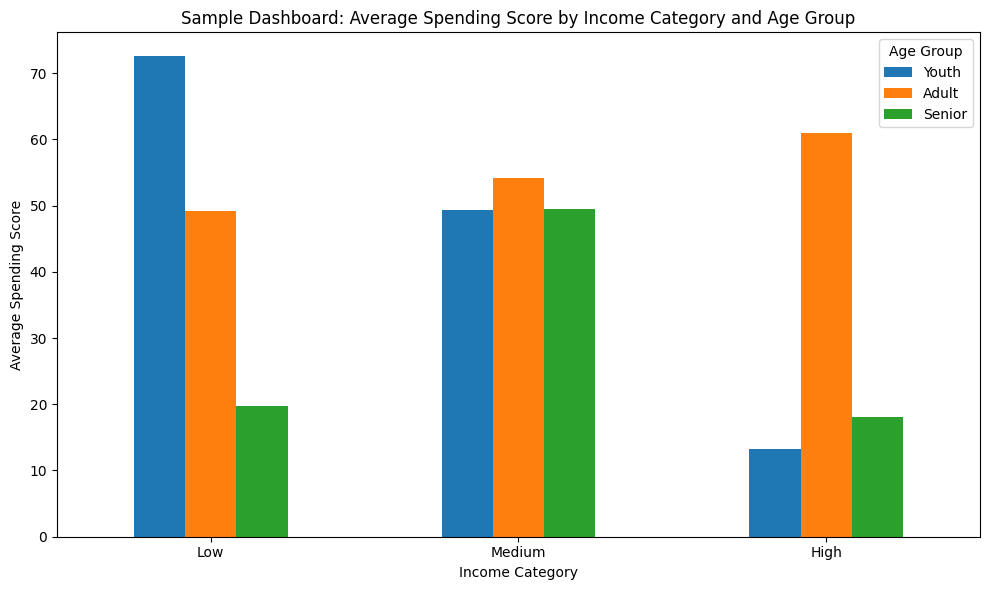

In [ ]:
dashboard.plot(kind='bar', figsize=(10, 6))
plt.title('Sample Dashboard: Average Spending Score by Income Category and Age Group')
plt.xlabel('Income Category')
plt.ylabel('Average Spending Score')
plt.xticks(rotation=0)
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

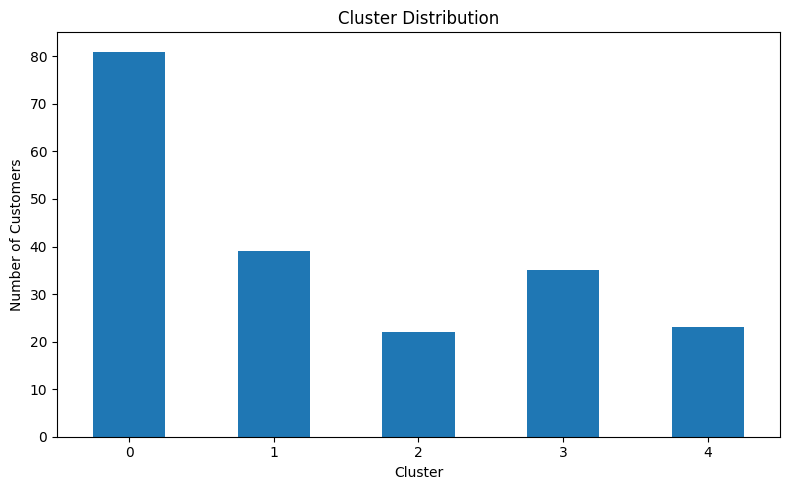

In [ ]:
# Additional dashboard view: cluster sizes
cluster_counts = clean_df['Cluster'].value_counts().sort_index()

cluster_counts.plot(kind='bar', figsize=(8, 5))
plt.title('Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Final Conclusion

This project successfully used the **Mall Customer Segmentation** dataset to support a retail analytics case study.

### Summary of what was achieved
- Two clear business questions were defined using **CRISP-DM**
- A **star schema** was proposed with one fact table and three dimensions
- ETL steps were demonstrated using **Pandas**
- The dataset was explored visually through EDA
- Features were scaled properly for K-Means
- The **Elbow Method** and **Silhouette Score** were used to justify the choice of **k = 5**
- Customers were segmented into meaningful groups
- Business recommendations were derived from the clusters
- Performance and ethics considerations were discussed
- A sample dashboard was created to demonstrate OLAP-style reporting

### Final business value
The notebook shows how a retail firm can turn customer data into useful decisions for:
- targeted marketing,
- customer retention,
- promotion design,
- and better strategic planning.